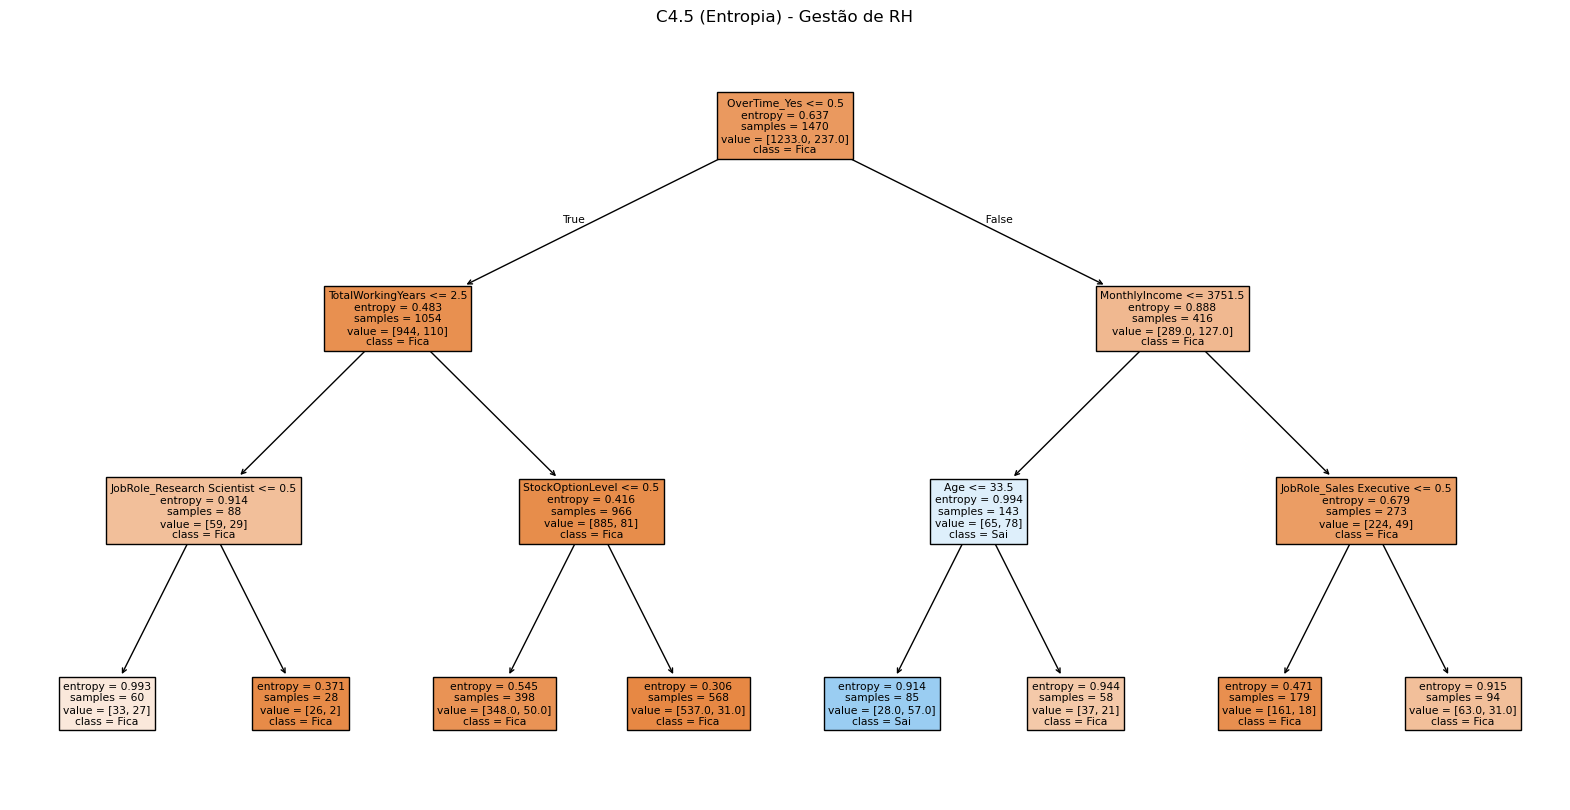

Base de Conhecimento C4.5 - RH:

|--- OverTime_Yes <= 0.50
|   |--- TotalWorkingYears <= 2.50
|   |   |--- JobRole_Research Scientist <= 0.50
|   |   |   |--- class: 0
|   |   |--- JobRole_Research Scientist >  0.50
|   |   |   |--- class: 0
|   |--- TotalWorkingYears >  2.50
|   |   |--- StockOptionLevel <= 0.50
|   |   |   |--- class: 0
|   |   |--- StockOptionLevel >  0.50
|   |   |   |--- class: 0
|--- OverTime_Yes >  0.50
|   |--- MonthlyIncome <= 3751.50
|   |   |--- Age <= 33.50
|   |   |   |--- class: 1
|   |   |--- Age >  33.50
|   |   |   |--- class: 0
|   |--- MonthlyIncome >  3751.50
|   |   |--- JobRole_Sales Executive <= 0.50
|   |   |   |--- class: 0
|   |   |--- JobRole_Sales Executive >  0.50
|   |   |   |--- class: 0



In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import matplotlib.pyplot as plt


df_hr = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

# PRÉ-PROCESSAMENTO
df_hr = df_hr.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1)
df_hr['Attrition'] = df_hr['Attrition'].map({'Yes': 1, 'No': 0})
df_hr_final = pd.get_dummies(df_hr, drop_first=True)

X_hr = df_hr_final.drop('Attrition', axis=1)
y_hr = df_hr_final['Attrition']

# ALGORITMO C4.5 (Entropy)
model_c45_hr = DecisionTreeClassifier(criterion='entropy', max_depth=3)
model_c45_hr.fit(X_hr, y_hr)

# RESULTADOS
plt.figure(figsize=(20,10))
plot_tree(model_c45_hr, feature_names=X_hr.columns, class_names=['Fica', 'Sai'], filled=True)
plt.title("C4.5 (Entropia) - Gestão de RH")
plt.show()

print("Base de Conhecimento C4.5 - RH:\n")
print(export_text(model_c45_hr, feature_names=list(X_hr.columns)))